## Šiame faile pateikiama *Yi-Peng 3* atvejo analizė

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime, timedelta, timezone

plt.style.use('bmh')
plt.rcParams['axes.facecolor'] = 'white'

In [3]:
df = pd.read_csv(
    '../data/414270000_20241118_sample(in).csv',
    parse_dates=['position_timestamp']
).set_index('position_timestamp')

df.head()

,created_at,static_timestamp,mmsi,latitude,longitude,speed,course,heading,imo,name,...,flag,draught,ship_type_code,ship_type,length,width,eta,destination,status,collection_type
position_timestamp,,,,,,,,,,,,,,,,,,,,,
2024-11-18 00:01:53+00:00,2024-11-18 00:17:52.000000 UTC,2024-11-17 23:57:56.000000 UTC,414270000,55.926158,17.388000,6.7,255.0,254,9224984,YI PENG 3,...,CN,14.5,70,DRY_BULK,224,32,2024-12-02 20:00:00.000000 UTC,PSD.EG,0,dynamic_classA
2024-11-18 00:03:30+00:00,2024-11-18 01:17:22.000000 UTC,2024-11-17 23:57:56.000000 UTC,414270000,55.925418,17.383202,6.8,255.1,255,9224984,YI PENG 3,...,CN,14.5,70,DRY_BULK,224,32,2024-12-02 20:00:00.000000 UTC,PSD.EG,0,dynamic_classA
2024-11-18 00:13:26+00:00,2024-11-18 00:21:25.000000 UTC,2024-11-18 00:09:56.000000 UTC,414270000,55.920237,17.349243,7.3,254.0,255,9224984,YI PENG 3,...,CN,14.5,70,DRY_BULK,224,32,2024-12-02 20:00:00.000000 UTC,PSD.EG,0,dynamic_classA
2024-11-18 00:17:03+00:00,2024-11-18 00:17:52.000000 UTC,2024-11-18 00:09:56.000000 UTC,414270000,55.918247,17.336458,7.3,254.4,255,9224984,YI PENG 3,...,CN,14.5,70,DRY_BULK,224,32,2024-12-02 20:00:00.000000 UTC,PSD.EG,0,dynamic_classA
2024-11-18 00:28:26+00:00,2024-11-18 00:41:56.000000 UTC,2024-11-18 00:21:56.000000 UTC,414270000,55.912168,17.296732,7.4,256.2,257,9224984,YI PENG 3,...,CN,14.5,70,DRY_BULK,224,32,2024-12-02 20:00:00.000000 UTC,PSD.EG,0,dynamic_classA


In [4]:
df_int = df.resample('60s')\
    ['latitude', 'longitude', 'speed', 'course', 'heading']\
    .median()\
    .interpolate('pchip')

In [5]:
df.columns

Index(['created_at', 'static_timestamp', 'mmsi', 'latitude', 'longitude',
       'speed', 'course', 'heading', 'imo', 'name', 'call_sign', 'flag',
       'draught', 'ship_type_code', 'ship_type', 'length', 'width', 'eta',
       'destination', 'status', 'collection_type'],
      dtype='object')

### COG kintamasis

Kursas virš žemės nuo 00:00 iki maždaug 02:30 UTC svyravo (euristiškai, vizualiai).
Tai galime interpretuoti per fizinę prizmę:

Laivą, tempiantį inkarą jūros dugnu, veikia panačios jėgos, kaip laivą, tempiamą laivo-vilkiko.

In [17]:
list( range(1,9,2) )

[1, 3, 5, 7]

In [20]:
[
    start_datetime + timedelta(hours=i)
    for i in range(1, 11, 2)
]
#     labels=[
#         f'{str(i).zfill(2)}:00'
#         for i in range(1, 11, 2)
#     ]
# )

[datetime.datetime(2024, 11, 18, 1, 0),
 datetime.datetime(2024, 11, 18, 3, 0),
 datetime.datetime(2024, 11, 18, 5, 0),
 datetime.datetime(2024, 11, 18, 7, 0),
 datetime.datetime(2024, 11, 18, 9, 0)]

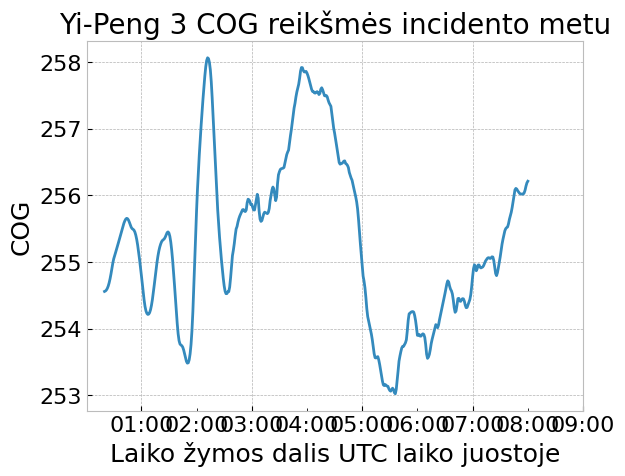

In [19]:
df_int['course']\
    .rolling(20)\
    .mean()\
    .loc[:datetime(2024,11,18,8,0, tzinfo=timezone.utc)]\
    .plot()

start_datetime = datetime(2024,11,18,0,0)

plt.xlabel('Laiko žymos dalis UTC laiko juostoje', size=18)
plt.ylabel('COG', size=18)
plt.title('Yi-Peng 3 COG reikšmės incidento metu', size=20)

plt.xticks(
    ticks=[
        start_datetime + timedelta(hours=i)
        for i in range(1, 11, 2)
    ],
    labels=[
        f'{str(i).zfill(2)}:00'
        for i in range(1, 11, 2)
    ]
)

plt.tick_params(axis='both', which='both', labelsize=16)
plt.show()